# From First Purchase to Loyal Customer

This analysis explores customer purchasing behavior in the **Brazilian E-Commerce Public Dataset by Olist**. The dataset contains information about orders, customers, products, sellers, payments, reviews, and delivery performance.

The main focus of the analysis is to understand **repeat-purchase behavior**: how common repeat purchases are, how long customers take to return, and which characteristics of the first purchase are associated with customers making another purchase.

## Goal of the Analysis

Identify patterns in **customer repeat-purchase behavior** and examine which characteristics of the first purchase are associated with a customer returning.

The analysis focuses on the customer journey from the **first purchase to a potential second purchase**, with particular attention to purchasing behavior, product categories, delivery performance, and customer reviews.

### Key Questions

To achieve this goal, the analysis seeks to answer the following questions:

1. How common are repeat purchases among Olist customers?
2. How much time typically passes between the first and second purchase?
3. How do first purchases differ between one-time and returning customers?
4. Is delivery performance associated with repeat purchasing?
5. Do some product categories have higher repeat-purchase rates?
6. What product-category transitions occur between the first and second purchase?
7. What does a fixed 180-day repeat-purchase cohort reveal about customer behavior?
8. Can information available from a customer's first purchase help identify customers who return within 180 days?

### Scope & Methodology

The analysis combines **SQL-based data modeling and validation** with Python-based exploratory and statistical analysis.

The raw Olist data was first loaded into **DuckDB** and transformed using **dbt**. Data quality checks and relationship validations were performed before creating customer-level analytical datasets.

The final analysis is performed using validated dbt models directly from DuckDB.

### Analysis Workflow

| Step | What was done | Why |
|---|---|---|
| **1. Raw data ingestion** | Loaded the Olist CSV tables into DuckDB | Creates a reproducible analytical database |
| **2. Data quality checks** | Checked nulls, duplicates, keys and relationships | Helps prevent incorrect joins and misleading results |
| **3. Customer identity** | Used `customer_unique_id` as the persistent customer identifier | Allows purchases from the same customer to be connected across orders |
| **4. Grain validation** | Investigated relationships between orders, items, payments and reviews | Prevents duplicated rows and inflated metrics |
| **5. Staging models** | Standardized the raw source tables using dbt | Creates a consistent foundation for further transformations |
| **6. Intermediate models** | Aggregated item, payment and review data to the order level before joining | Keeps each model at a clearly defined grain |
| **7. Customer-level model** | Created a one-row-per-customer behavioral dataset | Enables customer-level analysis |
| **8. Repeat-purchase cohort** | Defined a 180-day repeat-purchase outcome | Gives eligible customers the same minimum observation window |
| **9. Exploratory analysis** | Compared purchasing, delivery, review and category characteristics | Identifies patterns in customer behavior |
| **10. Statistical analysis** | Tests whether observed differences are meaningful | Goes beyond comparing averages alone |
| **11. Visualization** | Visualized the strongest patterns and findings | Makes the results easier to interpret |

## Dataset

The **Brazilian E-Commerce Public Dataset by Olist** contains approximately 100,000 orders from a Brazilian e-commerce marketplace.

The data is distributed across multiple related tables covering customers, orders, products, sellers, payments, reviews, and delivery information.

The analysis uses the following source tables:

| Table | Description | Main Grain |
|---|---|---|
| `customers` | Customer and location information | Customer record |
| `orders` | Order status and timestamps | Order |
| `order_items` | Products and sellers included in orders | Order item |
| `order_payments` | Payment transactions | Payment |
| `order_reviews` | Customer reviews and ratings | Review |
| `products` | Product attributes and categories | Product |
| `sellers` | Seller information | Seller |
| `category_translation` | Portuguese to English product category mapping | Category |
| `geolocation` | Geographic information by ZIP code prefix | ZIP prefix |

### Data Model

The source tables contain different levels of detail, so understanding their **grain and relationships** is important before combining them.

A simplified view of the main relationships is:

```text
Customer
   │
   └── Order
         │
         ├── Order Items ─── Product
         │                     │
         │                     └── Category
         │
         ├── Payments
         │
         ├── Reviews
         │
         └── Seller
```

One order can contain multiple items, multiple payment records, and in some cases multiple review records.

Because these tables have different grains, directly joining them can duplicate order-level values. To avoid this, item, payment, and review information was aggregated to the order level before being combined into the customer-level dataset.

The detailed data model and validation process are documented separately in `docs/`.

## Limitations

- The dataset represents one specific marketplace and time period.
- Repeat purchasing is measured as an association, not a causal outcome.
- The 180-day window excludes customers without at least 180 days of observation.

## Next Steps

The next stage is to investigate whether first-purchase characteristics can be used to predict repeat purchasing within 180 days.

---

In [1]:
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "olist.duckdb"

In [3]:
con = duckdb.connect(DB_PATH)

In [4]:
# Plotting style
sns.set_theme(
    style="white",
    context="notebook",
    font_scale=1.05
)

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.figsize": (8, 5)
})

---

## 1. Load Data

In [5]:
customer_df = con.execute("""
    SELECT *
    FROM mart_customer_behavior
""").df()

In [6]:
customer_df.head()

,customer_unique_id,order_count,customer_type,first_purchase_timestamp,last_purchase_timestamp,total_customer_value,average_order_value,total_items_purchased,average_review_score
0,299905e3934e9e181bfb2e164dd4b4f8,1,one-time,2017-07-29 11:55:02,2017-07-29 11:55:02,169.76,169.76,1.0,5.0
1,6da92ae920ab16fc4eceb8fcd7bd43ce,1,one-time,2017-11-30 22:02:15,2017-11-30 22:02:15,91.66,91.66,1.0,4.0
2,42f80af2e6c585667e4eb416859ae153,1,one-time,2018-01-22 19:22:22,2018-01-22 19:22:22,105.56,105.56,1.0,5.0
3,377bdfb2197d3b83c9e3f9502deabcfb,1,one-time,2017-12-02 14:28:03,2017-12-02 14:28:03,106.38,106.38,1.0,1.0
4,ac307db9d15fc5bb19b61298bd6bd1ed,1,one-time,2018-07-13 15:45:51,2018-07-13 15:45:51,423.67,423.67,2.0,3.0


In [7]:
customer_df.shape

(95420, 9)

In [8]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95420 entries, 0 to 95419
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        95420 non-null  str           
 1   order_count               95420 non-null  int64         
 2   customer_type             95420 non-null  str           
 3   first_purchase_timestamp  95420 non-null  datetime64[us]
 4   last_purchase_timestamp   95420 non-null  datetime64[us]
 5   total_customer_value      95420 non-null  float64       
 6   average_order_value       95420 non-null  float64       
 7   total_items_purchased     95420 non-null  float64       
 8   average_review_score      94721 non-null  float64       
dtypes: datetime64[us](2), float64(4), int64(1), str(2)
memory usage: 6.6 MB


---

## 2. Exploratory Data Analysis (EDA)

### 2.1. Customer Purchase Behavior

First, we compare one-time and returning customers to understand their purchasing behavior, customer value, and average review scores.

In [9]:
customer_summary = (
    customer_df
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_orders=("order_count", "mean"),
        avg_customer_value=("total_customer_value", "mean"),
        avg_order_value=("average_order_value", "mean"),
        avg_items=("total_items_purchased", "mean"),
        avg_review_score=("average_review_score", "mean")
    )
    .round(2)
)

customer_summary

,customers,avg_orders,avg_customer_value,avg_order_value,avg_items,avg_review_score
customer_type,,,,,,
one-time,92507,1.00,161.49,161.49,1.14,4.10
returning,2913,2.11,310.49,146.85,2.57,4.15


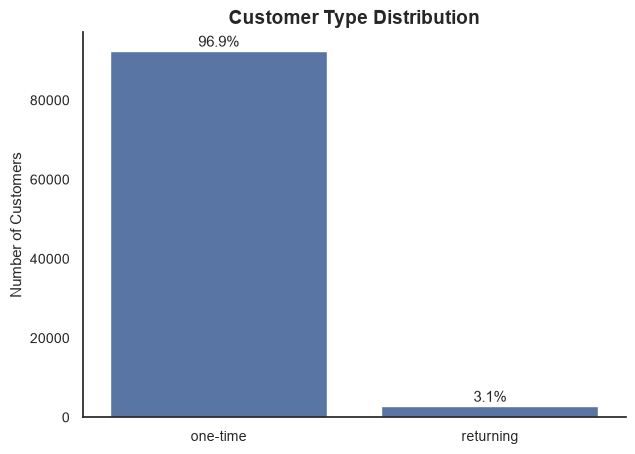

In [10]:
customer_counts = customer_df["customer_type"].value_counts()

plt.figure(figsize=(7, 5))

ax = sns.barplot(
    x=customer_counts.index,
    y=customer_counts.values
)

plt.title("Customer Type Distribution")
plt.xlabel("")
plt.ylabel("Number of Customers")

# Add percentages
total = customer_counts.sum()

for i, value in enumerate(customer_counts.values):
    percentage = value / total * 100
    ax.text(
        i,
        value + 1000,
        f"{percentage:.1f}%",
        ha="center",
        fontsize=11
    )

plt.show()

---

### 2.2. Time to Second Purchase

For customers who make a repeat purchase, we examine how long it takes them to return.

Understanding the timing of the second purchase helps reveal whether repeat purchasing happens mainly shortly after the first order or over a longer period.

In [11]:
returning_df = con.execute("""
    WITH customer_orders AS (
        SELECT
            customer_unique_id,
            order_purchase_timestamp,
            ROW_NUMBER() OVER (
                PARTITION BY customer_unique_id
                ORDER BY order_purchase_timestamp, order_id
            ) AS purchase_number
        FROM int_customer_orders
        WHERE total_order_value IS NOT NULL
    ),

    purchases AS (
        SELECT
            customer_unique_id,
            MAX(
                CASE
                    WHEN purchase_number = 1
                    THEN order_purchase_timestamp
                END
            ) AS first_purchase,
            MAX(
                CASE
                    WHEN purchase_number = 2
                    THEN order_purchase_timestamp
                END
            ) AS second_purchase
        FROM customer_orders
        GROUP BY customer_unique_id
    )

    SELECT
        customer_unique_id,
        DATE_DIFF(
            'day',
            CAST(first_purchase AS DATE),
            CAST(second_purchase AS DATE)
        ) AS days_to_second_purchase
    FROM purchases
    WHERE second_purchase IS NOT NULL
""").df()

returning_df.head()

,customer_unique_id,days_to_second_purchase
0,54732c804725f94304b9f2d1107a3d6e,219
1,56e3a158ef88285f2c15a83db0b13d93,148
2,5a2e847dd085d36e3ba8916b75e794ed,0
3,5c2b5c09534917d37857557d37ed9205,126
4,5cc1eb5a94ab59494d63f06a5c7eec15,0


In [12]:
returning_df["days_to_second_purchase"].describe()

count    2913.000000
mean       80.788534
std       110.231836
min         0.000000
25%         0.000000
50%        28.000000
75%       125.000000
max       609.000000
Name: days_to_second_purchase, dtype: float64

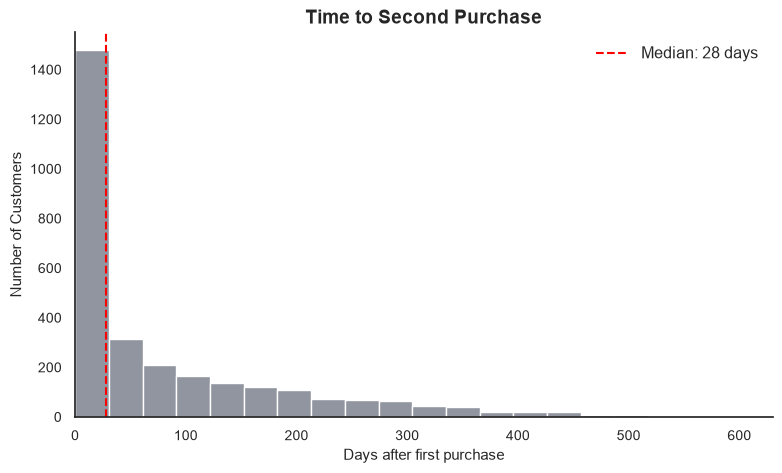

In [13]:
median_days = returning_df["days_to_second_purchase"].median()

plt.figure(figsize=(9, 5))

sns.histplot(
    data=returning_df,
    x="days_to_second_purchase",
    binwidth=30,
    color="#6B7280",
    edgecolor="white"
)

plt.axvline(
    median_days,
    linestyle="--",
    linewidth=1.5,
    color="#FF0000",
    label=f"Median: {median_days:.0f} days"
)

plt.title("Time to Second Purchase")
plt.xlabel("Days after first purchase")
plt.ylabel("Number of Customers")
plt.xlim(0, 630)
plt.legend(frameon=False)

plt.show()

---

### 2.3. First Purchase Characteristics

Next, we compare the first purchase of one-time and returning customers.

The goal is to identify whether differences in the initial order are associated with later repeat purchasing.

In [14]:
first_purchase_df = con.execute("""
    WITH customer_orders AS (
        SELECT
            customer_unique_id,
            order_id,
            order_purchase_timestamp,
            total_order_value,
            item_count,
            freight_value,
            average_review_score,

            ROW_NUMBER() OVER (
                PARTITION BY customer_unique_id
                ORDER BY order_purchase_timestamp, order_id
            ) AS purchase_number,

            COUNT(*) OVER (
                PARTITION BY customer_unique_id
            ) AS total_purchases

        FROM int_customer_orders
        WHERE total_order_value IS NOT NULL
    )

    SELECT
        customer_unique_id,
        total_purchases,
        total_order_value AS first_order_value,
        item_count AS first_order_items,
        freight_value AS first_order_freight,
        average_review_score AS first_review_score,

        CASE
            WHEN total_purchases >= 2 THEN 'returning'
            ELSE 'one-time'
        END AS customer_type

    FROM customer_orders
    WHERE purchase_number = 1
""").df()

first_purchase_df.head()

,customer_unique_id,total_purchases,first_order_value,first_order_items,first_order_freight,first_review_score,customer_type
0,00053a61a98854899e70ed204dd4bafe,1,419.18,2,37.18,1.0,one-time
1,00090324bbad0e9342388303bb71ba0a,1,63.66,1,13.71,5.0,one-time
2,000ec5bff359e1c0ad76a81a45cb598f,1,27.75,1,12.79,5.0,one-time
3,001a2bf0e46c684031af91fb2bce149d,1,36.73,1,11.85,4.0,one-time
4,001f3c4211216384d5fe59b041ce1461,1,35.84,1,10.96,3.0,one-time


In [15]:
first_purchase_summary = (
    first_purchase_df
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_first_order_value=("first_order_value", "mean"),
        avg_first_order_items=("first_order_items", "mean"),
        avg_first_order_freight=("first_order_freight", "mean"),
        avg_first_review=("first_review_score", "mean")
    )
    .round(2)
)

first_purchase_summary

,customers,avg_first_order_value,avg_first_order_items,avg_first_order_freight,avg_first_review
customer_type,,,,,
one-time,92507,161.49,1.14,22.82,4.10
returning,2913,147.09,1.22,22.85,4.15


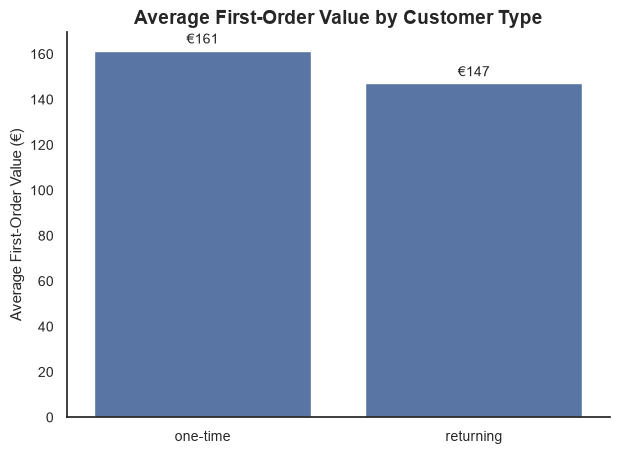

In [16]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=first_purchase_summary.reset_index(),
    x="customer_type",
    y="avg_first_order_value"
)

plt.title("Average First-Order Value by Customer Type")
plt.xlabel("")
plt.ylabel("Average First-Order Value (€)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="€%.0f",
        padding=3,
        fontsize=10
    )

plt.show()

---

### 2.4. Delivery Experience

We compare delivery time and late-delivery rates between one-time and returning customers.

The goal is to examine whether delivery performance is associated with repeat purchasing.

In [17]:
delivery_df = con.execute("""
    WITH customer_orders AS (
        SELECT
            customer_unique_id,
            order_id,
            order_purchase_timestamp,
            order_delivered_customer_date,
            order_estimated_delivery_date,

            ROW_NUMBER() OVER (
                PARTITION BY customer_unique_id
                ORDER BY order_purchase_timestamp, order_id
            ) AS purchase_number,

            COUNT(*) OVER (
                PARTITION BY customer_unique_id
            ) AS total_purchases

        FROM int_customer_orders
        WHERE total_order_value IS NOT NULL
    )

    SELECT
        customer_unique_id,

        DATE_DIFF(
            'day',
            CAST(order_purchase_timestamp AS DATE),
            CAST(order_delivered_customer_date AS DATE)
        ) AS delivery_days,

        CASE
            WHEN order_delivered_customer_date > order_estimated_delivery_date
            THEN 1
            ELSE 0
        END AS late_delivery,

        CASE
            WHEN total_purchases >= 2 THEN 'returning'
            ELSE 'one-time'
        END AS customer_type

    FROM customer_orders
    WHERE purchase_number = 1
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
""").df()

In [18]:
delivery_summary = (
    delivery_df
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "count"),
        avg_delivery_days=("delivery_days", "mean"),
        median_delivery_days=("delivery_days", "median"),
        late_delivery_rate=("late_delivery", "mean")
    )
)

delivery_summary["late_delivery_rate"] *= 100

delivery_summary.round(2)

,customers,avg_delivery_days,median_delivery_days,late_delivery_rate
customer_type,,,,
one-time,90450,12.51,10.0,8.18
returning,2835,12.37,10.0,6.77


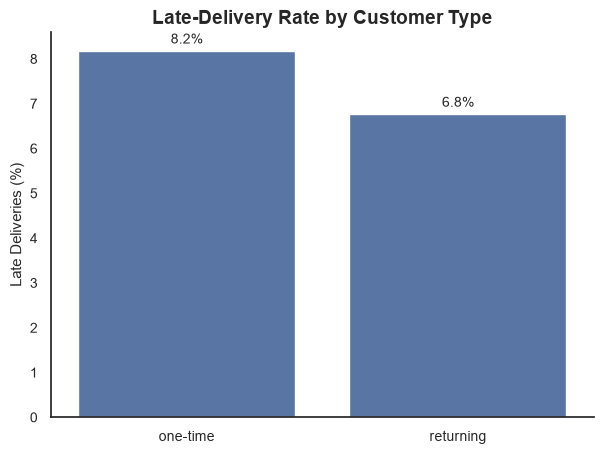

In [19]:
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=delivery_summary.reset_index(),
    x="customer_type",
    y="late_delivery_rate"
)

plt.title("Late-Delivery Rate by Customer Type")
plt.xlabel("")
plt.ylabel("Late Deliveries (%)")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10
    )

plt.show()

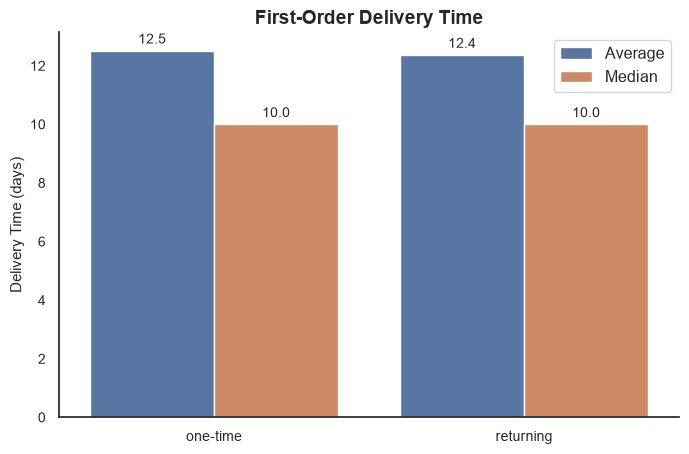

In [20]:
delivery_plot = (
    delivery_summary
    .reset_index()
    .melt(
        id_vars="customer_type",
        value_vars=["avg_delivery_days", "median_delivery_days"],
        var_name="metric",
        value_name="days"
    )
)

delivery_plot["metric"] = delivery_plot["metric"].map({
    "avg_delivery_days": "Average",
    "median_delivery_days": "Median"
})

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=delivery_plot,
    x="customer_type",
    y="days",
    hue="metric"
)

plt.title("First-Order Delivery Time")
plt.xlabel("")
plt.ylabel("Delivery Time (days)")
plt.legend(title="")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f",
        padding=3,
        fontsize=10
    )

plt.show()

> **Insight**
>
> Both groups have a median delivery time of 10 days, while average delivery time differs by only 0.1 day. 
> 
> The late-delivery rate is somewhat lower among returning customers (6.8% vs 8.2%), suggesting a small association between delivery performance and repeat purchasing. However, this difference does not establish a causal relationship.

---

### 2.5. Product Categories

We examine whether the product category purchased in the first order is associated with repeat purchasing.

Repeat-purchase rates are calculated for customers exposed to each category in their first order. Categories with very small customer counts are excluded to avoid unstable comparisons.

In [21]:
"""
Creating the category-level dataset
Using the enriched item model (dbt intermediate model: int_order_items_enriched):
"""

category_df = con.execute("""
    WITH first_orders AS (
        SELECT
            customer_unique_id,
            order_id,
            ROW_NUMBER() OVER (
                PARTITION BY customer_unique_id
                ORDER BY order_purchase_timestamp, order_id
            ) AS purchase_number,
            COUNT(*) OVER (
                PARTITION BY customer_unique_id
            ) AS total_purchases
        FROM int_customer_orders
        WHERE total_order_value IS NOT NULL
    ),

    first_order_categories AS (
        SELECT DISTINCT
            fo.customer_unique_id,
            fo.order_id,
            fo.total_purchases,
            oi.product_category_name_english AS category
        FROM first_orders fo
        JOIN int_order_items_enriched oi
            ON fo.order_id = oi.order_id
        WHERE fo.purchase_number = 1
          AND oi.product_category_name_english IS NOT NULL
    )

    SELECT
        category,
        COUNT(DISTINCT customer_unique_id) AS customers,
        COUNT(DISTINCT CASE
            WHEN total_purchases >= 2
            THEN customer_unique_id
        END) AS returning_customers
    FROM first_order_categories
    GROUP BY category
""").df()

category_df.head()

,category,customers,returning_customers
0,furniture_decor,6144,286
1,health_beauty,8568,242
2,electronics,2506,41
3,office_furniture,1246,27
4,musical_instruments,615,11


In [22]:
"""
Calculate the repeat rate
"""

category_df["repeat_rate"] = (
    category_df["returning_customers"]
    / category_df["customers"]
    * 100
)

In [23]:
"""
To keep categories with enough customers, use 500 first-order 
customers as our minimum threshold.
"""

category_analysis = (
    category_df[
        category_df["customers"] >= 500
    ]
    .sort_values("repeat_rate", ascending=False)
)

category_analysis

,category,customers,returning_customers,repeat_rate
53,home_appliances,690,62,8.985507
34,fashion_bags_accessories,1740,104,5.977011
0,furniture_decor,6144,286,4.654948
51,bed_bath_table,8955,408,4.556114
40,sports_leisure,7400,289,3.905405
61,garden_tools,3430,102,2.973761
26,pet_shop,1655,49,2.960725
43,computers_accessories,6464,188,2.908416
29,perfumery,3073,88,2.863651
1,health_beauty,8568,242,2.824463


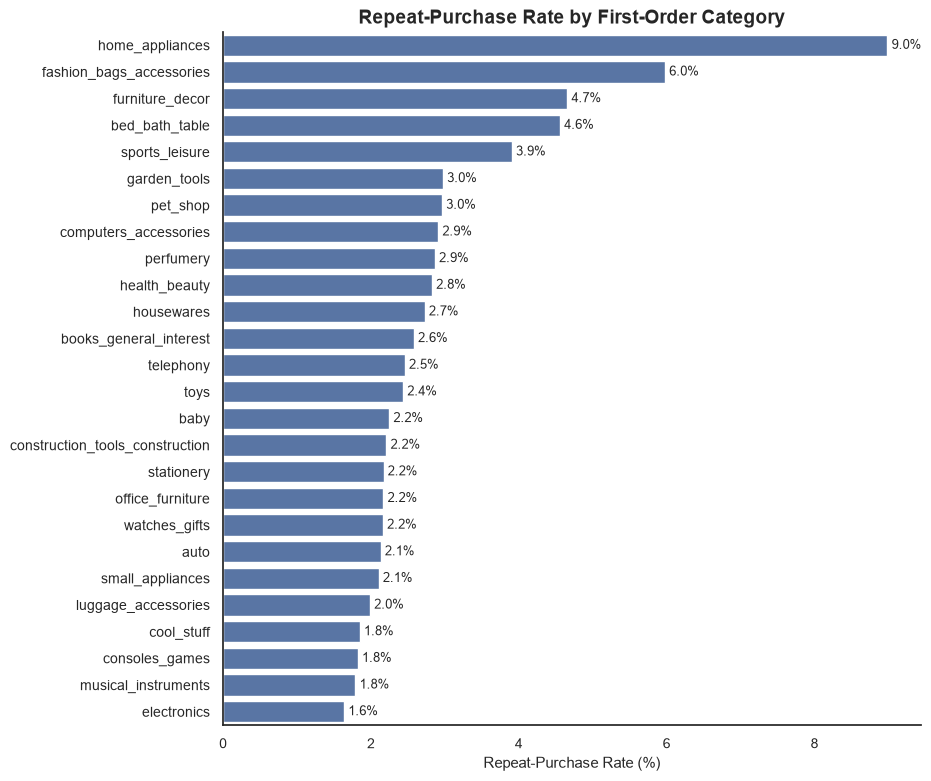

In [24]:
plt.figure(figsize=(9, 9))

ax = sns.barplot(
    data=category_analysis,
    y="category",
    x="repeat_rate"
)

plt.title("Repeat-Purchase Rate by First-Order Category")
plt.xlabel("Repeat-Purchase Rate (%)")
plt.ylabel("")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

plt.show()

> **Note:** A single order can contain products from multiple categories, so customers may appear in more than one category group. Repeat rates therefore represent the association between category exposure and repeat purchasing, not mutually exclusive customer segments.

The next we check how many customers are behind each category rate.

In [25]:
category_analysis.sort_values(
    "customers",
    ascending=False
).head(10)

,category,customers,returning_customers,repeat_rate
51,bed_bath_table,8955,408,4.556114
1,health_beauty,8568,242,2.824463
40,sports_leisure,7400,289,3.905405
43,computers_accessories,6464,188,2.908416
0,furniture_decor,6144,286,4.654948
46,housewares,5687,155,2.725514
62,watches_gifts,5461,118,2.160776
48,telephony,4111,101,2.456823
25,auto,3802,81,2.130458
15,toys,3780,92,2.433862


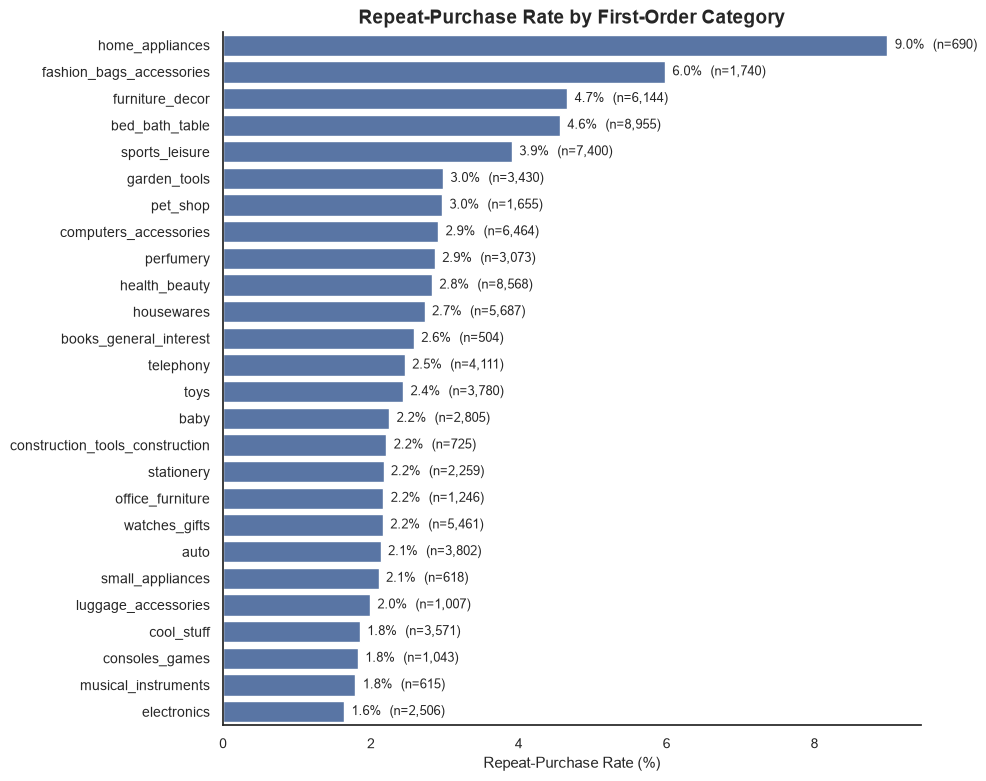

In [26]:
category_plot = category_analysis.sort_values(
    "repeat_rate",
    ascending=False
)

plt.figure(figsize=(9, 9))

ax = sns.barplot(
    data=category_plot,
    y="category",
    x="repeat_rate"
)

plt.title("Repeat-Purchase Rate by First-Order Category")
plt.xlabel("Repeat-Purchase Rate (%)")
plt.ylabel("")

for i, row in enumerate(category_plot.itertuples()):
    ax.text(
        row.repeat_rate + 0.1,
        i,
        f"{row.repeat_rate:.1f}%  (n={row.customers:,})",
        va="center",
        fontsize=9
    )

plt.show()

In [27]:
category_analysis[
    ["category", "customers", "returning_customers", "repeat_rate"]
].sort_values(
    "repeat_rate",
    ascending=False
).head(10)

,category,customers,returning_customers,repeat_rate
53,home_appliances,690,62,8.985507
34,fashion_bags_accessories,1740,104,5.977011
0,furniture_decor,6144,286,4.654948
51,bed_bath_table,8955,408,4.556114
40,sports_leisure,7400,289,3.905405
61,garden_tools,3430,102,2.973761
26,pet_shop,1655,49,2.960725
43,computers_accessories,6464,188,2.908416
29,perfumery,3073,88,2.863651
1,health_beauty,8568,242,2.824463


> **Insight:** Repeat-purchase rates vary considerably across first-order categories. Customers whose first order included home appliances had the highest observed repeat-purchase rate (9.0%), while electronics had one of the lowest (1.6%). This suggests that the product category included in a customer's first purchase is associated with different levels of subsequent repeat purchasing.

These differences should be interpreted as associations rather than causal effects, since customers may purchase products from multiple categories in their first order.

---

In [28]:
category_180d_df = con.execute("""
    SELECT DISTINCT
        r.customer_unique_id,
        r.returned_180d,
        oi.product_category_name_english AS category
    FROM mart_customer_repeat_180d r
    JOIN int_order_items_enriched oi
        ON r.customer_unique_id = oi.customer_unique_id
       AND oi.order_id = (
            SELECT order_id
            FROM int_customer_orders o
            WHERE o.customer_unique_id = r.customer_unique_id
              AND o.order_purchase_timestamp = r.first_purchase_timestamp
            ORDER BY o.order_id
            LIMIT 1
       )
    WHERE oi.product_category_name_english IS NOT NULL
""").df()

category_180d_df.head()

,customer_unique_id,returned_180d,category
0,961ca706a9f7e9d6a4ba81922cde9730,0,auto
1,9638cc22a57fed145c4f14dd4ad23940,0,sports_leisure
2,9ad7f351da31cd0b98d6387ebfb2f8d5,0,fashion_underwear_beach
3,9ba98a3b2aa42ee6dcb06da4ef7733c5,0,bed_bath_table
4,9c90aa9cb66638cee087f0d739075931,0,auto


In [29]:
category_180d_analysis = (
    category_180d_df
    .groupby("category")
    .agg(
        customers=("customer_unique_id", "nunique"),
        returning_customers=("returned_180d", "sum")
    )
    .reset_index()
)

category_180d_analysis["repeat_rate"] = (
    category_180d_analysis["returning_customers"]
    / category_180d_analysis["customers"]
    * 100
)

In [30]:
category_180d_analysis = (
    category_180d_analysis[
        category_180d_analysis["customers"] >= 500
    ]
    .sort_values("repeat_rate", ascending=False)
)

category_180d_analysis.head(10)

,category,customers,returning_customers,repeat_rate
28,fashion_bags_accessories,1209,69,5.707196
7,bed_bath_table,5649,292,5.169056
39,furniture_decor,3986,190,4.766683
65,sports_leisure,4796,197,4.107590
60,pet_shop,858,29,3.379953
43,health_beauty,4618,154,3.334777
15,computers_accessories,4083,130,3.183933
49,housewares,3093,82,2.651148
6,baby,1600,42,2.625000
42,garden_tools,2414,63,2.609776


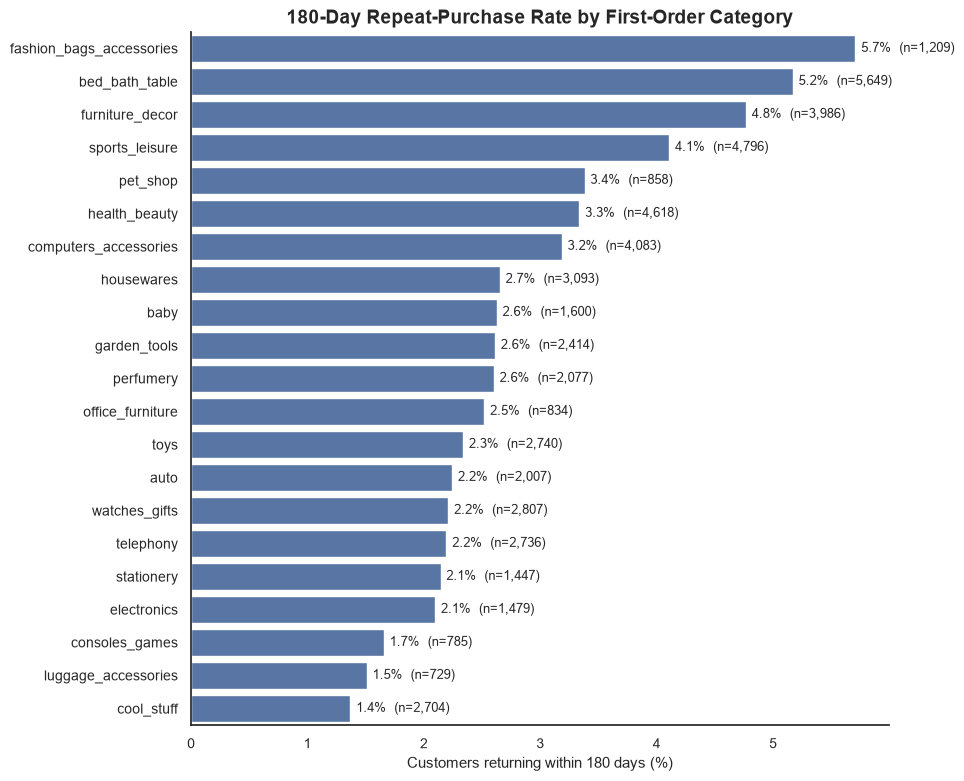

In [31]:
plt.figure(figsize=(9, 9))

ax = sns.barplot(
    data=category_180d_analysis,
    y="category",
    x="repeat_rate"
)

plt.title("180-Day Repeat-Purchase Rate by First-Order Category")
plt.xlabel("Customers returning within 180 days (%)")
plt.ylabel("")

for i, row in enumerate(category_180d_analysis.itertuples()):
    ax.text(
        row.repeat_rate + 0.05,
        i,
        f"{row.repeat_rate:.1f}%  (n={row.customers:,})",
        va="center",
        fontsize=9
    )

plt.show()

> **Insight:** 
> 
> Fashion bags & accessories has the highest observed rate at 5.7%, while cool stuff has the lowest at 1.4% among categories with at least 500 eligible customers. This variation suggests that first-order category may be associated with repeat-purchase behavior and is worth investigating further in the predictive analysis.
>
> These categories are not mutually exclusive because a customer may purchase products from multiple categories in the same first order. The results therefore describe category exposure rather than exclusive customer segments.

---

### 2.6. 180-Day Repeat Purchase

To compare customers fairly, we use a fixed 180-day observation window.

Customers whose first purchase occurred less than 180 days before the end of the dataset are excluded, because they do not have enough time to demonstrate whether they return.

The target variable `returned_180d` indicates whether a customer made a second purchase within 180 days of their first purchase.

In [32]:
customer_df_180d = con.execute("""
    SELECT *
    FROM mart_customer_repeat_180d
""").df()

customer_df_180d.shape

(58644, 11)

In [33]:
repeat_summary = (
    customer_df_180d["returned_180d"]
    .value_counts()
    .rename(index={0: "Did not return", 1: "Returned"})
    .reset_index()
)

repeat_summary.columns = ["customer_type", "customers"]

repeat_summary["percentage"] = (
    repeat_summary["customers"]
    / repeat_summary["customers"].sum()
    * 100
)

repeat_summary

,customer_type,customers,percentage
0,Did not return,56785,96.830025
1,Returned,1859,3.169975


C:\Users\Monika-PG\AppData\Local\Temp\ipykernel_9684\4219249349.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([


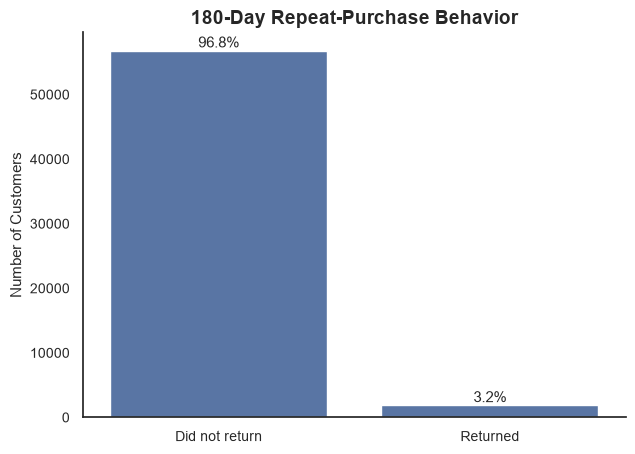

In [34]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=customer_df_180d,
    x="returned_180d"
)

plt.title("180-Day Repeat-Purchase Behavior")
plt.xlabel("")
plt.ylabel("Number of Customers")

ax.set_xticklabels([
    "Did not return",
    "Returned"
])

total = len(customer_df_180d)

for i, value in enumerate(
    customer_df_180d["returned_180d"].value_counts().sort_index()
):
    percentage = value / total * 100

    ax.text(
        i,
        value + 500,
        f"{percentage:.1f}%",
        ha="center",
        fontsize=11
    )

plt.show()

> **Insight:** 
> 
> Among the 58,644 customers with at least 180 days of observation, 1,859 (3.2%) made a second purchase within 180 days. 
> 
> The large imbalance between returning and non-returning customers will be important when we move to statistical analysis and predictive modeling.

---

### 2.7 Purchase Frequency

Most customers make only one purchase, while a small group makes multiple purchases. Examining the distribution shows how concentrated repeat purchasing is among the customer base.

In [35]:
purchase_frequency = (
    customer_df["order_count"]
    .value_counts()
    .sort_index()
)

purchase_frequency

order_count
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

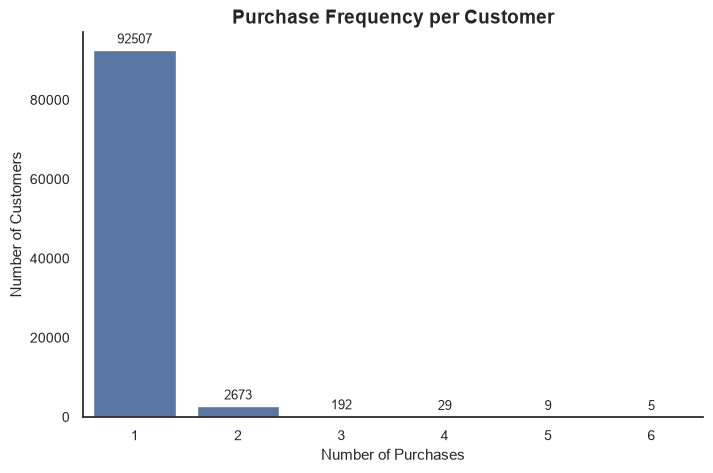

In [36]:
frequency_plot = (
    purchase_frequency
    .loc[purchase_frequency.index <= 6]
    .reset_index()
)

frequency_plot.columns = ["order_count", "customers"]

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=frequency_plot,
    x="order_count",
    y="customers"
)

plt.title("Purchase Frequency per Customer")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

plt.show()

> **Insight**
> 
> Customer purchasing is highly concentrated around a single purchase. Most customers in the dataset made only one purchase, while repeat purchasing beyond two orders is rare. This reinforces the strong imbalance between one-time and returning customers observed earlier.

---

## 3. Statistical Analysis

The exploratory analysis showed differences between customers who returned within 180 days and those who did not.

In this section, statistical tests are used to determine whether these differences are statistically significant.

The analysis focuses on:
- first-order value and number of items,
- first-order review score,
- delivery performance,
- and the relationship between first-order characteristics and repeat purchasing.

Because the dataset contains a large number of customers, statistical significance alone is not sufficient. Effect sizes and the magnitude of differences are also considered to assess practical relevance.

### 3.1 First-Purchase Characteristics

We first test whether the first purchase differs between customers who returned within 180 days and those who did not.

The variables considered are:
- first-order value,
- number of items in the first order,
- first-order review score.

These variables are not normally distributed and contain discrete values, so a non-parametric Mann–Whitney U test is used to compare the two customer groups.

In [37]:
# Compare first-order value between customers who returned and those who did not

returned_value = customer_df_180d.loc[
    customer_df_180d["returned_180d"] == 1,
    "first_order_value"
].dropna()

not_returned_value = customer_df_180d.loc[
    customer_df_180d["returned_180d"] == 0,
    "first_order_value"
].dropna()

stat, p_value = mannwhitneyu(
    returned_value,
    not_returned_value,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {stat:,.0f}")
print(f"p-value: {p_value:.6g}")

Mann–Whitney U statistic: 50,957,130
p-value: 0.0110787


In [38]:
summary = pd.DataFrame({
    "Group": ["Returned within 180d", "Did not return within 180d"],
    "Customers": [
        len(returned_value),
        len(not_returned_value)
    ],
    "Median first-order value": [
        returned_value.median(),
        not_returned_value.median()
    ],
    "Mean first-order value": [
        returned_value.mean(),
        not_returned_value.mean()
    ]
})

summary

,Group,Customers,Median first-order value,Mean first-order value
0,Returned within 180d,1859,100.24,147.632808
1,Did not return within 180d,56785,104.37,159.006953


> **Result:** 
> 
> The Mann–Whitney U test indicates a statistically significant difference in first-order value between customers who returned within 180 days and those who did not (p = 0.011).
> 
> However, the difference is relatively small in practical terms. The median first-order value differs by only about €4, while the mean differs by approximately €11. This suggests that although first-order value is statistically associated with repeat purchasing, the magnitude of the difference is limited.

### 3.2 First-Order Item Count

We next test whether the number of items purchased in the first order differs between customers who returned within 180 days and those who did not.

As item counts are discrete and strongly concentrated around small values, the Mann–Whitney U test is again used.

In [39]:
returned_items = customer_df_180d.loc[
    customer_df_180d["returned_180d"] == 1,
    "first_order_items"
].dropna()

not_returned_items = customer_df_180d.loc[
    customer_df_180d["returned_180d"] == 0,
    "first_order_items"
].dropna()

stat_items, p_value_items = mannwhitneyu(
    returned_items,
    not_returned_items,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {stat_items:,.0f}")
print(f"p-value: {p_value_items:.6g}")

Mann–Whitney U statistic: 55,004,919
p-value: 1.99026e-09


In [40]:
items_summary = pd.DataFrame({
    "Group": ["Returned within 180d", "Did not return within 180d"],
    "Customers": [
        len(returned_items),
        len(not_returned_items)
    ],
    "Median first-order items": [
        returned_items.median(),
        not_returned_items.median()
    ],
    "Mean first-order items": [
        returned_items.mean(),
        not_returned_items.mean()
    ]
})

items_summary

,Group,Customers,Median first-order items,Mean first-order items
0,Returned within 180d,1859,1.0,1.217321
1,Did not return within 180d,56785,1.0,1.136779


### 3.3 First-Order Review Score

We next examine whether customers who returned within 180 days gave different review scores for their first purchase.

Review scores are ordinal, discrete values from 1 to 5, so the Mann–Whitney U test is used to compare the two groups.

In [41]:
returned_reviews = customer_df_180d.loc[
    customer_df_180d["returned_180d"] == 1,
    "first_review_score"
].dropna()

not_returned_reviews = customer_df_180d.loc[
    customer_df_180d["returned_180d"] == 0,
    "first_review_score"
].dropna()

stat_reviews, p_value_reviews = mannwhitneyu(
    returned_reviews,
    not_returned_reviews,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {stat_reviews:,.0f}")
print(f"p-value: {p_value_reviews:.6g}")

Mann–Whitney U statistic: 52,271,006
p-value: 0.574308


In [42]:
review_summary = pd.DataFrame({
    "Group": ["Returned within 180d", "Did not return within 180d"],
    "Customers": [
        len(returned_reviews),
        len(not_returned_reviews)
    ],
    "Median first review": [
        returned_reviews.median(),
        not_returned_reviews.median()
    ],
    "Mean first review": [
        returned_reviews.mean(),
        not_returned_reviews.mean()
    ]
})

review_summary

,Group,Customers,Median first review,Mean first review
0,Returned within 180d,1844,5.0,4.071855
1,Did not return within 180d,56304,5.0,4.056275


### 3.4 Delivery Performance

We next examine whether late delivery is associated with repeat purchasing.

Unlike the previous variables, late delivery is a binary outcome: a first order was either delivered late or it was not. Therefore, a chi-square test of independence is used to compare the distribution of late and on-time deliveries between the two customer groups.

In [43]:
delivery_table = pd.crosstab(
    delivery_df["customer_type"],
    delivery_df["late_delivery"]
)

delivery_table

late_delivery,0,1
customer_type,,
one-time,83048,7402
returning,2643,192


In [44]:
chi2, p_value_delivery, dof, expected = chi2_contingency(
    delivery_table
)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {p_value_delivery:.6g}")

Chi-square statistic: 7.13
p-value: 0.00757442


In [45]:
delivery_rates = (
    delivery_df
    .groupby("customer_type")["late_delivery"]
    .agg(["count", "mean"])
    .reset_index()
)

delivery_rates["late_delivery_pct"] = delivery_rates["mean"] * 100

delivery_rates

,customer_type,count,mean,late_delivery_pct
0,one-time,90450,0.081835,8.183527
1,returning,2835,0.067725,6.772487


> **Result:** The chi-square test indicates a statistically significant association between first-order late delivery and 180-day repeat purchasing (p = 0.008).
> 
> Late deliveries occurred in 8.2% of first orders from customers who did not return, compared with 6.8% among customers who returned within 180 days. This represents a difference of approximately 1.4 percentage points.  
> 
> The statistical result suggests an association, but the relatively small difference in delivery rates indicates that the practical effect may be limited. This analysis does not establish that delivery performance causes repeat purchasing.

### 3.5 Multiple-Testing Correction

Several statistical tests are conducted in this section. To reduce the risk of interpreting a false-positive result as statistically significant, p-values are adjusted using the Benjamini–Hochberg procedure.

The corrected results are interpreted together with the observed differences and effect sizes rather than relying on p-values alone.

In [46]:
p_values = [
    p_value,              # first-order value
    p_value_items,        # first-order items
    p_value_reviews,      # first-order review
    p_value_delivery      # late delivery
]

test_names = [
    "First-order value",
    "First-order items",
    "First-order review",
    "Late delivery"
]

results = pd.DataFrame({
    "Test": test_names,
    "Raw p-value": p_values
})

results["Adjusted p-value"] = multipletests(
    results["Raw p-value"],
    method="fdr_bh"
)[1]

results["Significant (FDR < 0.05)"] = (
    results["Adjusted p-value"] < 0.05
)

results

,Test,Raw p-value,Adjusted p-value,Significant (FDR < 0.05)
0,First-order value,1.107871e-02,1.477161e-02,True
1,First-order items,1.990263e-09,7.961052e-09,True
2,First-order review,5.743082e-01,5.743082e-01,False
3,Late delivery,7.574425e-03,1.477161e-02,True


### 3.6 Effect Sizes

Statistical significance indicates whether an observed difference is unlikely to be explained by random variation, but it does not indicate how large or practically important the difference is.

To complement the p-values, effect sizes are calculated:

- Rank-biserial correlation for the Mann–Whitney U tests.
- Phi coefficient for the chi-square test of late delivery.

This helps distinguish statistically detectable differences from differences that may have meaningful practical relevance.

In [47]:
# Rank-biserial correlation for Mann–Whitney U tests
def rank_biserial(u_stat, n_group1, n_group2):
    return (2 * u_stat) / (n_group1 * n_group2) - 1


n_returned = len(returned_value)
n_not_returned = len(not_returned_value)

effect_value = rank_biserial(
    stat,
    n_returned,
    n_not_returned
)

effect_items = rank_biserial(
    stat_items,
    len(returned_items),
    len(not_returned_items)
)

effect_reviews = rank_biserial(
    stat_reviews,
    len(returned_reviews),
    len(not_returned_reviews)
)

# Phi coefficient for the 2x2 late-delivery table
n_delivery = delivery_table.to_numpy().sum()

effect_delivery = np.sqrt(
    chi2 / n_delivery
)

effect_sizes = pd.DataFrame({
    "Test": [
        "First-order value",
        "First-order items",
        "First-order review",
        "Late delivery"
    ],
    "Effect size": [
        effect_value,
        effect_items,
        effect_reviews,
        effect_delivery
    ]
})

effect_sizes

,Test,Effect size
0,First-order value,-0.034567
1,First-order items,0.042122
2,First-order review,0.006910
3,Late delivery,0.008743


### 3.7 Statistical Test Summary

The statistical results are summarized below, combining the observed differences, adjusted p-values, and effect sizes.

This provides a more complete interpretation than statistical significance alone, particularly given the large sample size.

In [48]:
statistical_results = pd.DataFrame({
    "Test": [
        "First-order value",
        "First-order items",
        "First-order review",
        "Late delivery"
    ],
    "Raw p-value": [
        p_value,
        p_value_items,
        p_value_reviews,
        p_value_delivery
    ],
    "Adjusted p-value": [
        results.loc[0, "Adjusted p-value"],
        results.loc[1, "Adjusted p-value"],
        results.loc[2, "Adjusted p-value"],
        results.loc[3, "Adjusted p-value"]
    ],
    "Effect size": [
        effect_value,
        effect_items,
        effect_reviews,
        effect_delivery
    ],
    "Significant": [
        results.loc[0, "Significant (FDR < 0.05)"],
        results.loc[1, "Significant (FDR < 0.05)"],
        results.loc[2, "Significant (FDR < 0.05)"],
        results.loc[3, "Significant (FDR < 0.05)"]
    ]
})

statistical_results

,Test,Raw p-value,Adjusted p-value,Effect size,Significant
0,First-order value,1.107871e-02,1.477161e-02,-0.034567,True
1,First-order items,1.990263e-09,7.961052e-09,0.042122,True
2,First-order review,5.743082e-01,5.743082e-01,0.006910,False
3,Late delivery,7.574425e-03,1.477161e-02,0.008743,True


> **Insights** 
> 
> Three of the four tested relationships remain statistically significant after correcting for multiple comparisons: first-order value, first-order item count, and late delivery.
>
> However, all observed effect sizes are very small. This indicates that although these variables show statistically detectable differences between the groups, they do not individually provide a strong separation between customers who return within 180 days and those who do not.
> 
> First-order review score shows neither statistical significance nor a meaningful effect.
> 
> These findings suggest that repeat purchasing is unlikely to be explained by any single first-order characteristic. A combination of customer, order, product, and experience-related variables may provide more useful predictive information, which motivates the predictive modeling stage.

### 3.8 Statistical Conclusions

The statistical analysis identified statistically significant differences in three of the four tested first-purchase characteristics:

- **First-order value** showed a statistically significant difference between the groups, but the effect size was very small.
- **First-order item count** was also statistically significant, with a very small effect.
- **Late delivery** showed a statistically significant association with repeat purchasing, but the effect size was negligible.
- **First-order review score** showed no statistically significant difference.

After correcting for multiple comparisons using the Benjamini–Hochberg procedure, the same three relationships remained statistically significant.

Overall, the results indicate that individual first-purchase characteristics provide only weak separation between customers who return within 180 days and those who do not. This suggests that repeat purchasing is better investigated using a combination of customer, order, product, and delivery-related features.

These findings motivate the predictive modeling stage, where multiple features can be evaluated together.

---

## 4. Predictive Modeling

The exploratory and statistical analyses showed that individual first-purchase characteristics have relatively weak relationships with repeat purchasing.

The next step is to evaluate whether a combination of first-purchase characteristics can better distinguish customers who return within 180 days from those who do not.

The target variable is:

- `returned_180d = 1` — the customer made a second purchase within 180 days
- `returned_180d = 0` — the customer did not make a second purchase within 180 days

Only customers with at least 180 days of observation are included, ensuring that each customer has the same opportunity to demonstrate repeat purchasing.

### Modeling Principle: Avoiding Target Leakage

The model is designed to simulate what could be known about a customer after their first purchase.

Therefore, only information available at or shortly after the first purchase is used as a predictor.

Variables describing future purchases or the customer's overall purchasing history are excluded because they would introduce target leakage and make the model unrealistically informative.

### 4.1 Modeling Dataset

The predictive dataset is based on the `mart_customer_repeat_180d` dbt model.

Each row represents one eligible customer, with the first purchase used to construct the predictor variables and the 180-day repeat-purchase outcome used as the target.

Before modeling, the available variables are reviewed to separate valid predictors from variables that would introduce target leakage.

In [49]:
customer_df_180d.columns.tolist()

['customer_unique_id',
 'first_purchase_timestamp',
 'first_order_value',
 'first_order_items',
 'first_order_freight',
 'first_review_score',
 'delivery_days',
 'late_delivery',
 'second_purchase_timestamp',
 'observation_days',
 'returned_180d']

In [50]:
customer_df_180d.info()

<class 'pandas.DataFrame'>
RangeIndex: 58644 entries, 0 to 58643
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   customer_unique_id         58644 non-null  str           
 1   first_purchase_timestamp   58644 non-null  datetime64[us]
 2   first_order_value          58644 non-null  float64       
 3   first_order_items          58644 non-null  int64         
 4   first_order_freight        58644 non-null  float64       
 5   first_review_score         58148 non-null  float64       
 6   delivery_days              57158 non-null  Int64         
 7   late_delivery              57158 non-null  Int32         
 8   second_purchase_timestamp  2356 non-null   datetime64[us]
 9   observation_days           58644 non-null  int64         
 10  returned_180d              58644 non-null  int32         
dtypes: Int32(1), Int64(1), datetime64[us](2), float64(3), int32(1), int64(2), str(

In [51]:
customer_df_180d[
    [
        "first_review_score",
        "delivery_days",
        "late_delivery"
    ]
].isna().sum()

first_review_score     496
delivery_days         1486
late_delivery         1486
dtype: int64

### 4.2 Missing-Value Strategy

Some first-order features contain missing values:

- `first_review_score`: 496 missing values
- `delivery_days`: 1,486 missing values
- `late_delivery`: 1,486 missing values

Missing delivery information is meaningful and should not automatically be interpreted as an on-time delivery.

Rather than removing these customers, missing values will be handled within the machine-learning preprocessing pipeline.

For numeric variables, missing values will be imputed using the median.

For binary delivery status, missing values will be imputed using the most frequent value. Missing-value indicators will also be retained so that the model can distinguish an imputed value from an originally observed value.

This approach avoids losing observations while preserving information about missingness.

In [52]:
missingness_summary = pd.DataFrame({
    "Feature": [
        "first_review_score",
        "delivery_days",
        "late_delivery"
    ],
    "Missing": [
        customer_df_180d["first_review_score"].isna().sum(),
        customer_df_180d["delivery_days"].isna().sum(),
        customer_df_180d["late_delivery"].isna().sum()
    ],
    "Missing %": [
        customer_df_180d["first_review_score"].isna().mean() * 100,
        customer_df_180d["delivery_days"].isna().mean() * 100,
        customer_df_180d["late_delivery"].isna().mean() * 100
    ]
})

missingness_summary

,Feature,Missing,Missing %
0,first_review_score,496,0.845781
1,delivery_days,1486,2.533934
2,late_delivery,1486,2.533934


In [53]:
target_summary = (
    customer_df_180d["returned_180d"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Did not return",
        1: "Returned within 180d"
    })
    .to_frame("Customers")
)

target_summary["Percentage"] = (
    target_summary["Customers"]
    / target_summary["Customers"].sum()
    * 100
)

target_summary

,Customers,Percentage
returned_180d,,
Did not return,56785,96.830025
Returned within 180d,1859,3.169975


### 4.3 Feature Selection and Train-Test Split

The model uses six features describing the customer's first purchase experience:

- `first_order_value`
- `first_order_items`
- `first_order_freight`
- `first_review_score`
- `delivery_days`
- `late_delivery`

The target is `returned_180d`.

Customer identifiers and variables containing future information are excluded to prevent target leakage.

The data is split into training and test sets using a stratified split. Stratification preserves the proportion of returning customers in both datasets, which is important because only around 3% of eligible customers return within 180 days.

In [54]:
feature_cols = [
    "first_order_value",
    "first_order_items",
    "first_order_freight",
    "first_review_score",
    "delivery_days",
    "late_delivery"
]

X = customer_df_180d[feature_cols].copy()
y = customer_df_180d["returned_180d"].copy()

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (58644, 6)
Target: (58644,)


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (46915, 6)
Test set: (11729, 6)


In [56]:
split_summary = pd.DataFrame({
    "Dataset": ["Full", "Training", "Test"],
    "Customers": [
        len(y),
        len(y_train),
        len(y_test)
    ],
    "Returning": [
        y.sum(),
        y_train.sum(),
        y_test.sum()
    ],
    "Return rate (%)": [
        y.mean() * 100,
        y_train.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary

,Dataset,Customers,Returning,Return rate (%)
0,Full,58644,1859,3.169975
1,Training,46915,1487,3.169562
2,Test,11729,372,3.171626


### 4.4 Preprocessing Pipeline

Missing values are handled inside the preprocessing pipeline so that imputation parameters are learned only from the training data.

Numeric features use median imputation, while binary `late_delivery` uses the most frequent value.

Missing-value indicators are added for these features so the model can retain information about whether a value was originally missing.

The preprocessing is fitted on the training set and then applied to the test set, preventing information from the test data from influencing model training.

In [57]:
numeric_features = [
    "first_order_value",
    "first_order_items",
    "first_order_freight",
    "first_review_score",
    "delivery_days"
]

binary_features = [
    "late_delivery"
]

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

binary_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    )
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features)
])

### 4.5 Baseline Model

Logistic Regression is used as the baseline model because it provides an interpretable starting point for binary classification.

The target is highly imbalanced, with only around 3% of customers returning within 180 days. To account for this imbalance, the model uses `class_weight="balanced"` so that the minority class receives greater weight during training.

Because the model is sensitive to feature scale, numeric variables are standardized after imputation.

The baseline will be evaluated using precision, recall, F1 score, ROC AUC, and PR AUC. Accuracy is not used as the primary metric because a model predicting almost every customer as non-returning could achieve high accuracy while failing to identify returning customers.

In [58]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

binary_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    )
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("binary", binary_pipeline, binary_features)
])

In [59]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        )
    )
])

In [60]:
baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['first_order_value','first_order_items','first_order_freight', 'first_review_score','delivery_days','late_delivery']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [61]:
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

In [62]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

baseline_metrics = {
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC AUC": roc_auc_score(y_test, y_pred_proba),
    "PR AUC": average_precision_score(y_test, y_pred_proba)
}

baseline_metrics

{'Precision': 0.03539659006671608,
 'Recall': 0.5134408602150538,
 'F1': 0.06622746185852982,
 'ROC AUC': 0.5391809892245888,
 'PR AUC': 0.04128059869593593}

**Baseline result:** The Logistic Regression model achieves a PR AUC of 0.041, compared with a positive-class baseline of approximately 0.032. This indicates that the model captures some signal beyond the class-prevalence baseline, but the improvement is modest.

At the default classification threshold, the model identifies 51.3% of returning customers, but precision is only 3.5%. In other words, the model captures about half of the positive cases while producing a large number of false positives.

The ROC AUC of 0.539 also indicates relatively limited discriminatory power.

These results suggest that the available first-purchase features alone provide limited predictive information about 180-day repeat purchasing.

### 4.6 Confusion Matrix

The confusion matrix shows how the baseline model classifies customers at the default probability threshold of 0.5.

This helps illustrate the trade-off between identifying returning customers and generating false positives.

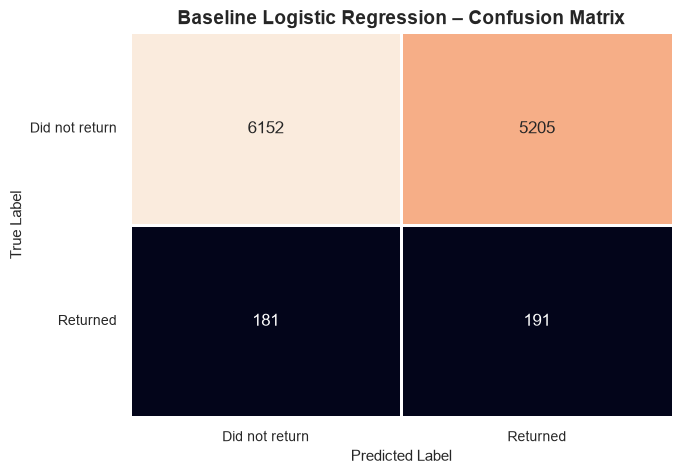

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cbar=False,
    linewidths=1,
    linecolor="white"
)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticklabels(["Did not return", "Returned"])
ax.set_yticklabels(["Did not return", "Returned"], rotation=0)

plt.title("Baseline Logistic Regression – Confusion Matrix")
plt.show()

**Observation:** At the default 0.5 classification threshold, the model identifies 191 of the 372 returning customers in the test set, corresponding to approximately 51% recall.

However, it also produces 5,205 false positives. This results in very low precision because the returning class is highly imbalanced.

The confusion matrix highlights the trade-off introduced by the `class_weight="balanced"` setting: the model becomes more sensitive to the minority class, but at the cost of a large number of false positives.

### 4.7 Precision–Recall Curve

Because the positive class is highly imbalanced, the classification threshold can substantially affect precision and recall.

The precision–recall curve evaluates the model across different probability thresholds and shows the trade-off between identifying returning customers and limiting false positives.

Average precision (PR AUC) is used as the main summary metric because it focuses on performance for the minority class.

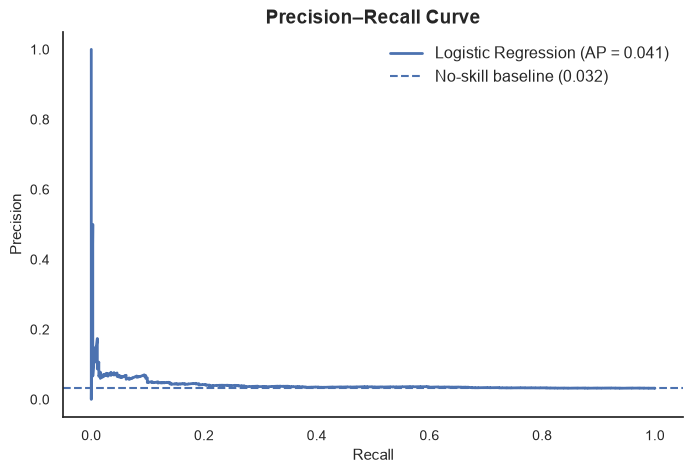

In [64]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_pred_proba
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Logistic Regression (AP = {baseline_metrics['PR AUC']:.3f})"
)

plt.axhline(
    y.mean(),
    linestyle="--",
    linewidth=1.5,
    label=f"No-skill baseline ({y.mean():.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(frameon=False)
plt.show()

**Observation:** The Logistic Regression model achieves an average precision of 0.041, compared with the no-skill baseline of 0.032. This represents a modest improvement over the prevalence-based baseline.

However, precision declines rapidly as recall increases, indicating that the model has limited ability to distinguish returning customers from non-returning customers. The available first-purchase features therefore provide only weak predictive signal when used on their own.

### 4.8 Probability Calibration

Before adjusting the classification threshold, we examine whether the predicted probabilities are reasonably calibrated.

A well-calibrated model should assign probabilities that correspond approximately to the observed frequency of the outcome. For example, among customers assigned a predicted probability of around 10%, roughly 10% would be expected to return within 180 days.

Calibration is particularly relevant for this project because the model produces probabilities of repeat purchasing rather than only binary classifications.

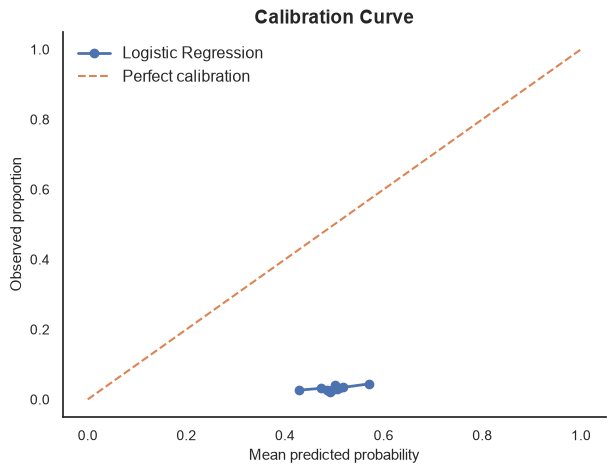

In [65]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    y_pred_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 5))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    linewidth=2,
    label="Logistic Regression"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion")
plt.title("Calibration Curve")
plt.legend(frameon=False)
plt.show()

In [66]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_test,
    y_pred_proba
)

print(f"Brier score: {brier:.4f}")

Brier score: 0.2486


**Calibration result:** The class-weighted Logistic Regression model is poorly calibrated. Predicted probabilities are concentrated around 0.4–0.6, while the observed proportion of returning customers remains close to the 3% prevalence of the target class.

The Brier score is 0.249, indicating that the raw predicted probabilities should not be interpreted as reliable estimates of a customer's probability of returning.

This behavior is expected to some extent because `class_weight="balanced"` changes the classification objective to give greater importance to the minority class. Therefore, the model's ranking performance and classification metrics are more informative here than its raw probability estimates.

Probability calibration would require a separate calibration procedure if reliable predicted probabilities were needed.

### 4.9 Model Comparison

Logistic Regression provides a simple and interpretable baseline, but it assumes a linear relationship between the predictors and the log-odds of repeat purchasing.

A tree-based model is evaluated next to determine whether nonlinear relationships or interactions between first-purchase characteristics provide additional predictive signal.

The models are compared using the same train-test split and the same target definition.

PR AUC is treated as the primary comparison metric because the target class is highly imbalanced. ROC AUC, precision, recall, and F1 are also reported for context.

In [67]:
rf_numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    )
])

rf_binary_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent",
            add_indicator=True
        )
    )
])

rf_preprocessor = ColumnTransformer([
    ("numeric", rf_numeric_pipeline, numeric_features),
    ("binary", rf_binary_pipeline, binary_features)
])

In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", rf_preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [69]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int32](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['first_order_value','first_order_items','first_order_freight', 'first_review_score','delivery_days','late_delivery']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'

In [70]:
rf_pred = rf_model.predict(X_test)
rf_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [71]:
rf_metrics = {
    "Precision": precision_score(y_test, rf_pred),
    "Recall": recall_score(y_test, rf_pred),
    "F1": f1_score(y_test, rf_pred),
    "ROC AUC": roc_auc_score(y_test, rf_pred_proba),
    "PR AUC": average_precision_score(y_test, rf_pred_proba)
}

rf_metrics

{'Precision': 0.050387596899224806,
 'Recall': 0.03494623655913978,
 'F1': 0.04126984126984127,
 'ROC AUC': 0.5191962751408112,
 'PR AUC': 0.03473398303344838}

In [72]:
model_comparison = pd.DataFrame({
    "Logistic Regression": baseline_metrics,
    "Random Forest": rf_metrics
}).T

model_comparison

,Precision,Recall,F1,ROC AUC,PR AUC
Logistic Regression,0.035397,0.513441,0.066227,0.539181,0.041281
Random Forest,0.050388,0.034946,0.041270,0.519196,0.034734


**Model comparison:** The Random Forest model does not improve on the Logistic Regression baseline.

Logistic Regression achieves a PR AUC of 0.041, compared with 0.035 for Random Forest. It also achieves substantially higher recall (51.3% vs. 3.5%) and F1 score (6.6% vs. 4.1%).

The results suggest that the available first-purchase features do not contain strong nonlinear patterns that improve repeat-purchase prediction. With this feature set, the simpler Logistic Regression model provides better predictive performance.

### 4.10 Adding First-Order Product Breadth

The initial models used only transaction and delivery characteristics.

The exploratory analysis also showed variation in repeat-purchase rates across product categories. Instead of assigning each multi-category order to a single category, a broader product-context feature is created: the number of distinct product categories purchased in the first order.

This feature captures product breadth while preserving the multi-category nature of orders.